# Event Display: Real Spill vs Synthetic Spill

This notebook displays one spill (tree entry) from one or more ROOTRacker files and compares it against a synthetic sample with the same number of particle entries.

Synthetic source options:
- Use pre-generated `synthetic_samples.parquet`
- Generate a fresh sample from a saved `generator.pth` checkpoint

## Notebook Plan

1. Load spill-level particle records from `RooTrackerTree` (one event entry = one spill).
2. Build a real-particle DataFrame (`x,y,z,px,py,pz,pdg,monitor_id`).
3. Build a synthetic DataFrame with exactly the same row count as the selected spill.
4. Convert synthetic feature-space columns to display-space cartesian coordinates.
5. Plot side-by-side event displays (3D and projections).
6. Print quick sanity checks (counts, ranges, feature availability).

In [81]:
import glob
import os
import sys
from typing import Optional, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import awkward as ak
import uproot
import pyarrow.parquet as pq

sns.set(style="whitegrid")
pd.set_option('display.max_columns', 200)

In [82]:
# ----------------------
# User configuration
# ----------------------
TRUTH_PARQUET = '/home/hep/jcc525/cleaned_data/pdgNone_monitor4.parquet'
SYNTHETIC_PARQUET = '/home/hep/jcc525/gan_particle_physics/gan_results/neutron/synthetic_samples.parquet'
SPILL_SIZE_N = 200000
TRUTH_READ_ROWS = SPILL_SIZE_N   # only first N truth rows are read into memory
TRUTH_SAMPLE_MODE = 'random'   # 'random' | 'sequential'
TRUTH_SAMPLE_SEED = 42
SYNTH_SAMPLE_SEED = 123

# PDG filter options: None (all), single int (e.g. 13), or list (e.g. [13, -13, 11])
# PDG_FILTER = [13, -13, 211, -211]  # Example: only muons and anti-muons
PDG_FILTER = [2112]

# Optional manual PDG assignment for synthetic samples.
# Use None to preserve any existing synthetic `pdg` values.
SYNTHETIC_PDG_OVERRIDE = 2112

# Spatial filter: clip r (radial distance) to this maximum value (mm)
SPACE_FILTER = 350

# Keep these for optional checkpoint generation path in this notebook
SYNTH_MODE = 'pregenerated'  # 'pregenerated' | 'checkpoint'
GAN_SRC_DIR = '/home/hep/jcc525/gan_particle_physics/src'
GAN_RUN_DIR = '/home/hep/jcc525/gan_particle_physics/gan_results/e_theta_constraint'
GENERATOR_CHECKPOINT = os.path.join(GAN_RUN_DIR, 'generator.pth')
TRAIN_PARQUET = '/home/hep/jcc525/cleaned_data/pdg13_monitor4.parquet'
DEVICE = 'cuda'

## Functions

In [83]:
def load_truth_pseudo_spill(
    truth_parquet: str,
    n_rows: int,
    mode: str = 'random',
    seed: int = 42,
    read_rows: Optional[int] = None,
    pdg_filter=None,
    space_filter: Optional[float] = None,
) -> pd.DataFrame:
    n_rows = int(max(1, n_rows))
    read_rows = int(max(n_rows, read_rows if read_rows is not None else n_rows))

    truth_raw = _read_first_n_parquet_rows(truth_parquet, n_rows=read_rows)
    if len(truth_raw) == 0:
        raise ValueError(f'No rows read from truth parquet: {truth_parquet}')

    truth_raw = _apply_pdg_filter(truth_raw, pdg_filter=pdg_filter)
    if len(truth_raw) == 0:
        raise ValueError(f'No truth rows remain after PDG filter: {pdg_filter}')

    truth_disp = synthetic_features_to_display(truth_raw)
    
    # Sample first, then apply space filter to ensure consistent particle counts
    truth_spill = make_pseudo_spill(truth_disp, n_rows=n_rows, mode=mode, seed=seed)
    
    if space_filter is not None and 'r' in truth_spill.columns:
        truth_spill = truth_spill.loc[truth_spill['r'] < space_filter].copy()
        if len(truth_spill) == 0:
            raise ValueError(f'No truth rows remain after space filter (r < {space_filter})')
    
    return truth_spill

In [84]:
def load_pregenerated_synthetic(path: str, n_rows: int, seed: int = 42, pdg_filter=None, pdg_override=None, space_filter: Optional[float] = None) -> pd.DataFrame:
    synth = pd.read_parquet(path)
    if len(synth) == 0:
        raise ValueError(f'Synthetic parquet is empty: {path}')

    synth = assign_synthetic_pdg(synth, pdg_override=pdg_override)
    synth = _apply_pdg_filter(synth, pdg_filter=pdg_filter)
    if len(synth) == 0:
        raise ValueError(f'No synthetic rows remain after PDG filter: {pdg_filter}')

    synth = synthetic_features_to_display(synth)
    
    # Sample first, then apply space filter to ensure consistent particle counts
    replace = len(synth) < n_rows
    synth = synth.sample(n=n_rows, replace=replace, random_state=seed).reset_index(drop=True)
    
    if space_filter is not None and 'r' in synth.columns:
        synth = synth.loc[synth['r'] < space_filter].copy()
        if len(synth) == 0:
            raise ValueError(f'No synthetic rows remain after space filter (r < {space_filter})')

    return synth

In [85]:
def generate_synthetic_from_checkpoint(n_rows: int, pdg_override=None) -> pd.DataFrame:
    import torch

    if GAN_SRC_DIR not in sys.path:
        sys.path.insert(0, GAN_SRC_DIR)

    from evaluate_saved_generator import (
        _infer_generator_architecture,
        _create_generator,
        _generate_synthetic_samples,
        _compute_normalization_stats,
    )
    from data_loader import load_preprocessed_data

    device = DEVICE if (DEVICE == 'cpu' or torch.cuda.is_available()) else 'cpu'
    state_dict = torch.load(GENERATOR_CHECKPOINT, map_location='cpu')
    inferred = _infer_generator_architecture(state_dict)

    train_df = load_preprocessed_data(TRAIN_PARQUET)
    model_type = 'wgan-gp' if inferred.get('normalization') == 'layernorm' else 'gan'
    mean, std = _compute_normalization_stats(train_df, model_type=model_type)

    generator = _create_generator(
        model_type=model_type,
        latent_dim=int(inferred['latent_dim']),
        output_dim=int(inferred['output_dim']),
        hidden_dims=list(inferred['hidden_dims']),
        normalization=str(inferred['normalization']),
    ).to(device)
    generator.load_state_dict(state_dict, strict=True)

    synth_np = _generate_synthetic_samples(
        generator=generator,
        n_samples=n_rows,
        latent_dim=int(inferred['latent_dim']),
        mean=mean,
        std=std,
        device=device,
        batch_size=8192,
        feature_names=list(train_df.columns),
        apply_angle_clipping=(model_type == 'wgan-gp'),
    )

    synth_df = pd.DataFrame(synth_np, columns=train_df.columns)
    synth_df = assign_synthetic_pdg(synth_df, pdg_override=pdg_override)
    return synthetic_features_to_display(synth_df)

In [ ]:
def _shared_numeric_columns(real_df: pd.DataFrame, synth_df: pd.DataFrame) -> list[str]:
    shared = [c for c in real_df.columns if c in synth_df.columns]
    numeric = [c for c in shared if pd.api.types.is_numeric_dtype(real_df[c]) and pd.api.types.is_numeric_dtype(synth_df[c])]
    return numeric


def print_variable_means_before_plot(real_df: pd.DataFrame, synth_df: pd.DataFrame) -> None:
    cols = _shared_numeric_columns(real_df, synth_df)
    if not cols:
        print('No shared numeric columns to summarize.')
        return

    mean_df = pd.DataFrame({
        'real_mean': real_df[cols].mean(numeric_only=True),
        'synthetic_mean': synth_df[cols].mean(numeric_only=True),
    })
    mean_df['abs_diff'] = (mean_df['real_mean'] - mean_df['synthetic_mean']).abs()
    mean_df = mean_df.sort_index()

    print('\n--- Means of all shared numeric variables (before plotting) ---')
    print(mean_df.to_string(float_format=lambda x: f'{x:.6f}'))


def _ensure_xyz(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    if 'x' not in out.columns:
        out['x'] = 0.0

    has_yz = ('y' in out.columns) and ('z' in out.columns)
    if not has_yz and {'r', 'sin_phi_s', 'cos_phi_s'}.issubset(out.columns):
        out['y'] = out['r'] * out['cos_phi_s']
        out['z'] = out['r'] * out['sin_phi_s']

    if 'y' not in out.columns:
        out['y'] = np.nan
    if 'z' not in out.columns:
        out['z'] = np.nan

    return out


def _downsample(df: pd.DataFrame, max_points: int, seed: int = 42) -> pd.DataFrame:
    if len(df) <= max_points:
        return df
    return df.sample(n=max_points, random_state=seed).reset_index(drop=True)


def _annotate_count_2d(ax, count: int, label: str = 'n'):
    ax.text(
        0.98,
        0.98,
        f'{label}={count:,}',
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.75, edgecolor='none'),
    )


def _annotate_count_3d(ax, count: int, label: str = 'n'):
    ax.text2D(
        0.98,
        0.98,
        f'{label}={count:,}',
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.75, edgecolor='none'),
    )


def _finite_min_max(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return None
    return float(arr.min()), float(arr.max())


def _shared_axis_limits(real_df: pd.DataFrame, synth_df: pd.DataFrame, columns: list[str]) -> dict[str, tuple[float, float]]:
    limits: dict[str, tuple[float, float]] = {}
    for col in columns:
        r = _finite_min_max(real_df[col].to_numpy()) if col in real_df.columns else None
        s = _finite_min_max(synth_df[col].to_numpy()) if col in synth_df.columns else None
        candidates = [x for x in (r, s) if x is not None]
        if not candidates:
            continue
        lo = min(v[0] for v in candidates)
        hi = max(v[1] for v in candidates)
        if np.isclose(lo, hi):
            pad = 1.0 if np.isclose(lo, 0.0) else abs(lo) * 0.05
            lo -= pad
            hi += pad
        limits[col] = (lo, hi)
    return limits


def _normalize_pdg(value):
    if pd.isna(value):
        return 'unknown'
    try:
        return int(value)
    except Exception:
        return 'unknown'


def _build_pdg_color_map(real_df: pd.DataFrame, synth_df: pd.DataFrame) -> dict:
    pdg_series = []
    if 'pdg' in real_df.columns:
        pdg_series.append(real_df['pdg'])
    if 'pdg' in synth_df.columns:
        pdg_series.append(synth_df['pdg'])

    if not pdg_series:
        return {'unknown': (0.55, 0.55, 0.55)}

    combined = pd.concat(pdg_series, ignore_index=True).map(_normalize_pdg)
    unique_pdgs = sorted([v for v in combined.unique() if v != 'unknown'])

    color_map = {'unknown': (0.55, 0.55, 0.55)}
    if unique_pdgs:
        palette = sns.color_palette('tab20', n_colors=len(unique_pdgs))
        for i, pdg in enumerate(unique_pdgs):
            color_map[pdg] = palette[i]
    return color_map


def _pdg_colors_for_df(df: pd.DataFrame, color_map: dict):
    if 'pdg' not in df.columns:
        keys = pd.Series(['unknown'] * len(df), index=df.index)
    else:
        keys = df['pdg'].map(_normalize_pdg)
    colors = keys.map(lambda k: color_map.get(k, color_map['unknown']))
    return colors, keys


def plot_3d_event_display(real_df: pd.DataFrame, synth_df: pd.DataFrame, max_points: int = 30000):
    from matplotlib.lines import Line2D

    real_base = _ensure_xyz(real_df)
    synth_base = _ensure_xyz(synth_df)

    real_cols = ['x', 'y', 'z'] + (['pdg'] if 'pdg' in real_base.columns else [])
    synth_cols = ['x', 'y', 'z'] + (['pdg'] if 'pdg' in synth_base.columns else [])

    real_xyz = _downsample(real_base[real_cols], max_points=max_points, seed=42)
    synth_xyz = _downsample(synth_base[synth_cols], max_points=max_points, seed=123)

    color_map = _build_pdg_color_map(real_base, synth_base)
    real_colors, real_keys = _pdg_colors_for_df(real_xyz, color_map)
    synth_colors, synth_keys = _pdg_colors_for_df(synth_xyz, color_map)

    # Show total count and displayed count
    real_total = len(real_base)
    synth_total = len(synth_base)
    real_displayed = len(real_xyz)
    synth_displayed = len(synth_xyz)

    fig = plt.figure(figsize=(14, 16))

    ax1 = fig.add_subplot(211, projection='3d')
    ax1.scatter(real_xyz['z'], real_xyz['x'], real_xyz['y'], s=2, alpha=0.22, c=list(real_colors))
    ax1.set_title(f'Real 3D (total n={real_total:,}, displayed n={real_displayed:,})')
    ax1.set_xlabel('z')
    ax1.set_ylabel('x')
    ax1.set_zlabel('y')
    _annotate_count_3d(ax1, real_total, label='n_total')

    ax2 = fig.add_subplot(212, projection='3d')
    ax2.scatter(synth_xyz['z'], synth_xyz['x'], synth_xyz['y'], s=2, alpha=0.22, c=list(synth_colors))
    ax2.set_title(f'Synthetic 3D (total n={synth_total:,}, displayed n={synth_displayed:,})')
    ax2.set_xlabel('z')
    ax2.set_ylabel('x')
    ax2.set_zlabel('y')
    _annotate_count_3d(ax2, synth_total, label='n_total')

    xyz_limits = _shared_axis_limits(real_xyz, synth_xyz, ['x', 'y', 'z'])
    if all(k in xyz_limits for k in ['x', 'y', 'z']):
        z_lim = xyz_limits['z']
        x_lim = xyz_limits['x']
        y_lim = xyz_limits['y']

        ax1.set_xlim(z_lim)
        ax1.set_ylim(x_lim)
        ax1.set_zlim(y_lim)
        ax2.set_xlim(z_lim)
        ax2.set_ylim(x_lim)
        ax2.set_zlim(y_lim)

        span_z = max(z_lim[1] - z_lim[0], 1e-9)
        span_x = max(x_lim[1] - x_lim[0], 1e-9)
        span_y = max(y_lim[1] - y_lim[0], 1e-9)
        ax1.set_box_aspect([span_z, span_x, span_y])
        ax2.set_box_aspect([span_z, span_x, span_y])

    legend_keys = sorted([k for k in color_map.keys() if k != 'unknown'])
    has_unknown = ('unknown' in set(real_keys)) or ('unknown' in set(synth_keys))
    if has_unknown:
        legend_keys.append('unknown')

    legend_handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[k], markersize=7, label=f'pdg={k}' if k != 'unknown' else 'pdg=unknown')
        for k in legend_keys
    ]
    if legend_handles:
        fig.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), frameon=True)

    plt.tight_layout(rect=[0, 0, 0.94, 1])
    plt.show()


def plot_cylindrical_views(real_df: pd.DataFrame, synth_df: pd.DataFrame):
    fig, axes = plt.subplots(2, 3, figsize=(17, 9))

    projection_pairs = [
        ('x', 'r'),
        ('sin_phi_s', 'cos_phi_s'),
        ('sin_theta', 'cos_theta'),
    ]

    for i, (xv, yv) in enumerate(projection_pairs):
        pair_limits = _shared_axis_limits(real_df, synth_df, [xv, yv])
        if xv in real_df.columns and yv in real_df.columns:
            sns.scatterplot(data=real_df, x=xv, y=yv, s=2, alpha=0.25, ax=axes[0, i], color='tab:blue', edgecolor=None)
            axes[0, i].set_title(f'Real: {xv} vs {yv}')
            _annotate_count_2d(axes[0, i], len(real_df))
        else:
            axes[0, i].text(0.5, 0.5, f'Missing columns:\n{xv}, {yv}', ha='center', va='center')
            axes[0, i].set_title('Real (unavailable)')

        if xv in synth_df.columns and yv in synth_df.columns:
            sns.scatterplot(data=synth_df, x=xv, y=yv, s=2, alpha=0.25, ax=axes[1, i], color='tab:orange', edgecolor=None)
            axes[1, i].set_title(f'Synthetic: {xv} vs {yv}')
            _annotate_count_2d(axes[1, i], len(synth_df))
        else:
            axes[1, i].text(0.5, 0.5, f'Missing columns:\n{xv}, {yv}', ha='center', va='center')
            axes[1, i].set_title('Synthetic (unavailable)')

        if xv in pair_limits:
            axes[0, i].set_xlim(pair_limits[xv])
            axes[1, i].set_xlim(pair_limits[xv])
        if yv in pair_limits:
            axes[0, i].set_ylim(pair_limits[yv])
            axes[1, i].set_ylim(pair_limits[yv])

    plt.tight_layout()
    plt.show()


def plot_cylindrical_marginals(real_df: pd.DataFrame, synth_df: pd.DataFrame):
    preferred = ['x', 'r', 'sin_phi_s', 'cos_phi_s', 'sin_theta', 'cos_theta', 'phi_p', 'log_t', 'log1p_p_mag', 'log1p_r', 'p_mag']
    cols = [c for c in preferred if c in real_df.columns and c in synth_df.columns]

    if not cols:
        print('No shared cylindrical variables available for marginal plots.')
        return

    n_cols = 3
    n_rows = int(np.ceil(len(cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3.5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(cols):
        ax = axes[i]
        sns.histplot(real_df[col], bins=80, stat='density', color='tab:blue', alpha=0.35, label='real', ax=ax)
        sns.histplot(synth_df[col], bins=80, stat='density', color='tab:orange', alpha=0.35, label='synthetic', ax=ax)
        ax.set_title(col)
        ax.legend()
        _annotate_count_2d(ax, len(real_df), label='n_real')
        ax.text(
            0.98,
            0.88,
            f'n_synth={len(synth_df):,}',
            transform=ax.transAxes,
            ha='right',
            va='top',
            fontsize=9,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.75, edgecolor='none'),
        )

    for j in range(len(cols), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


def plot_correlation_matrices(real_df: pd.DataFrame, synth_df: pd.DataFrame):
    preferred = ['x', 'r', 'sin_phi_s', 'cos_phi_s', 'sin_theta', 'cos_theta', 'phi_p', 'log_t', 'log1p_p_mag', 'log1p_r', 'p_mag']
    cols = [c for c in preferred if c in real_df.columns and c in synth_df.columns]
    if len(cols) < 2:
        print('Not enough shared variables for correlation matrices.')
        return

    corr_real = real_df[cols].corr(numeric_only=True)
    corr_synth = synth_df[cols].corr(numeric_only=True)
    corr_diff = (corr_real - corr_synth).abs()

    fig, axes = plt.subplots(1, 3, figsize=(26, 8))

    sns.heatmap(
        corr_real,
        ax=axes[0],
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        annot=True,
        fmt='.2f',
        annot_kws={'size': 8},
        linewidths=0.3,
        linecolor='white',
    )
    axes[0].set_title('Real correlation matrix')

    sns.heatmap(
        corr_synth,
        ax=axes[1],
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        annot=True,
        fmt='.2f',
        annot_kws={'size': 8},
        linewidths=0.3,
        linecolor='white',
    )
    axes[1].set_title('Synthetic correlation matrix')

    sns.heatmap(
        corr_diff,
        ax=axes[2],
        cmap='magma',
        vmin=0,
        vmax=1,
        center=None,
        square=True,
        annot=True,
        fmt='.2f',
        annot_kws={'size': 8},
        linewidths=0.3,
        linecolor='white',
    )
    axes[2].set_title('|Real - Synthetic| correlation difference')

    plt.tight_layout()
    plt.show()

## Outputs

In [87]:
if not os.path.exists(TRUTH_PARQUET):
    raise FileNotFoundError(f'Truth parquet not found: {TRUTH_PARQUET}')

if SYNTH_MODE == 'pregenerated':
    if not os.path.exists(SYNTHETIC_PARQUET):
        raise FileNotFoundError(f'Synthetic parquet not found: {SYNTHETIC_PARQUET}')
elif SYNTH_MODE == 'checkpoint':
    if not os.path.exists(GENERATOR_CHECKPOINT):
        raise FileNotFoundError(f'Generator checkpoint not found: {GENERATOR_CHECKPOINT}')
else:
    raise ValueError(f'Unsupported SYNTH_MODE: {SYNTH_MODE}')

real_spill_df = load_truth_pseudo_spill(
    truth_parquet=TRUTH_PARQUET,
    n_rows=SPILL_SIZE_N,
    mode=TRUTH_SAMPLE_MODE,
    seed=TRUTH_SAMPLE_SEED,
    read_rows=TRUTH_READ_ROWS,
    pdg_filter=PDG_FILTER,
    space_filter=SPACE_FILTER,
)

print('Using truth source:')
print(f'  {TRUTH_PARQUET}')
print(f'Pseudo-spill size requested (n): {SPILL_SIZE_N:,}')
print(f'Truth read limit (first N rows): {TRUTH_READ_ROWS:,}')
print(f'Truth sampling mode: {TRUTH_SAMPLE_MODE}')
print(f'PDG filter: {PDG_FILTER}')
print(f'Space filter (r < {SPACE_FILTER}): applied')
print(f'✅ Actual particles loaded: {len(real_spill_df):,}')

describe_numeric_summary(real_spill_df, label='Real (truth parquet pseudo-spill)')
real_spill_df.head()

Using truth source:
  /home/hep/jcc525/cleaned_data/pdgNone_monitor4.parquet
Pseudo-spill size requested (n): 200,000
Truth read limit (first N rows): 200,000
Truth sampling mode: random
PDG filter: [2112]
Space filter (r < 350): applied
✅ Actual particles loaded: 92,178
--- Real (truth parquet pseudo-spill) summary ---
Rows: 92,178
Numeric columns: 16

Means:
pdg          2112.000000
log_t           6.848973
x              37.892473
r             221.600583
sin_phi_s       0.032861
cos_phi_s      -0.098147
p_mag          51.166392
sin_theta       0.850432
cos_theta      -0.012382
phi_p           1.284316
y             -18.865542
z               7.884664
px             -0.157923
py              4.006714
pz             34.279819
monitor_id           NaN


,pdg,log_t,x,r,sin_phi_s,cos_phi_s,p_mag,sin_theta,cos_theta,phi_p,y,z,px,py,pz,monitor_id
1,2112,6.845481,-0.040000,100.778332,-0.895275,-0.445513,10.616447,0.921563,-0.388228,1.625127,-44.898083,-90.224356,-4.121604,-0.531297,9.769292,NaN
2,2112,6.846422,-0.040000,166.172531,0.608614,-0.793466,42.136852,0.846579,0.532262,1.809200,-131.852318,101.134941,22.427862,-8.424054,34.663246,NaN
5,2112,6.845928,-0.040000,108.659142,-0.995311,-0.096728,30.033138,0.952922,-0.303215,1.872619,-10.510397,-108.149621,-9.106495,-8.507388,27.325546,NaN
6,2112,6.845896,196.823191,345.677545,-0.135836,-0.990731,29.074826,0.727447,-0.686164,-0.386483,-342.473572,-46.955482,-19.950085,19.590361,-7.972285,NaN
7,2112,6.846108,-0.040000,142.631126,0.303649,-0.952784,34.931189,0.726408,-0.687263,1.287280,-135.896649,43.309800,-24.006926,7.098045,24.361306,NaN


In [88]:
n_particles = len(real_spill_df)

if SYNTH_MODE == 'pregenerated':
    synth_spill_df = load_pregenerated_synthetic(
        SYNTHETIC_PARQUET,
        n_rows=n_particles,
        seed=SYNTH_SAMPLE_SEED,
        pdg_filter=PDG_FILTER,
        pdg_override=SYNTHETIC_PDG_OVERRIDE,
        space_filter=SPACE_FILTER,
    )
elif SYNTH_MODE == 'checkpoint':
    synth_base = generate_synthetic_from_checkpoint(
        n_rows=n_particles,
        pdg_override=SYNTHETIC_PDG_OVERRIDE,
    )
    synth_base = _apply_pdg_filter(synth_base, pdg_filter=PDG_FILTER)
    synth_spill_df = synth_base.copy()
    if SPACE_FILTER is not None and 'r' in synth_spill_df.columns:
        synth_spill_df = synth_spill_df.loc[synth_spill_df['r'] < SPACE_FILTER].copy()
else:
    raise ValueError(f'Unsupported SYNTH_MODE: {SYNTH_MODE}')

print('Using synthetic source:')
if SYNTH_MODE == 'pregenerated':
    print(f'  {SYNTHETIC_PARQUET}')
else:
    print(f'  checkpoint: {GENERATOR_CHECKPOINT}')
print(f'Synthetic mode: {SYNTH_MODE}')
print(f'Target particle count (from real spill): {n_particles:,}')
print(f'PDG filter: {PDG_FILTER}')
print(f'Synthetic PDG override: {SYNTHETIC_PDG_OVERRIDE}')
print(f'Space filter (r < {SPACE_FILTER}): applied')
print(f'✅ Actual particles loaded: {len(synth_spill_df):,}')

if len(synth_spill_df) != len(real_spill_df):
    print(f'⚠️  Particle count mismatch! Real={len(real_spill_df):,}, Synthetic={len(synth_spill_df):,}')
    # Take the minimum count to ensure both datasets have the same size
    min_count = min(len(real_spill_df), len(synth_spill_df))
    print(f'📊 Equalizing to minimum count: {min_count:,}')
    real_spill_df = real_spill_df.sample(n=min_count, random_state=42).reset_index(drop=True)
    synth_spill_df = synth_spill_df.sample(n=min_count, random_state=123).reset_index(drop=True)
    print(f'✅ Final particle counts - Real={len(real_spill_df):,}, Synthetic={len(synth_spill_df):,}')

describe_numeric_summary(synth_spill_df, label='Synthetic (generated parquet pseudo-spill)')
synth_spill_df.head()

Using synthetic source:
  /home/hep/jcc525/gan_particle_physics/gan_results/neutron/synthetic_samples.parquet
Synthetic mode: pregenerated
Target particle count (from real spill): 92,178
PDG filter: [2112]
Synthetic PDG override: 2112
Space filter (r < 350): applied
✅ Actual particles loaded: 39,297
⚠️  Particle count mismatch! Real=92,178, Synthetic=39,297
📊 Equalizing to minimum count: 39,297
✅ Final particle counts - Real=39,297, Synthetic=39,297
--- Synthetic (generated parquet pseudo-spill) summary ---
Rows: 39,297
Numeric columns: 18

Means:
log_t            6.848998
x               27.629246
sin_phi_s        0.007337
cos_phi_s       -0.107205
sin_theta        0.857261
cos_theta       -0.003371
phi_p            1.396118
log1p_p_mag      3.486470
log1p_r          5.211591
pdg           2112.000000
r              208.274155
p_mag           51.091679
y              -20.968472
z                0.732167
px              -0.111729
py               1.798485
pz              35.159096
moni

,log_t,x,sin_phi_s,cos_phi_s,sin_theta,cos_theta,phi_p,log1p_p_mag,log1p_r,pdg,r,p_mag,y,z,px,py,pz,monitor_id
0,6.845545,-1.317668,-0.977712,0.209953,0.931185,-0.364547,0.788083,2.896796,5.696813,2112,296.916321,17.116016,62.338444,-290.298523,-6.239590,11.239693,11.300217,NaN
1,6.845554,0.919339,-0.945764,-0.324855,0.698607,0.715505,0.218925,2.826014,4.670043,2112,105.702278,15.878056,-34.337910,-99.969391,11.360835,10.827764,2.409074,NaN
2,6.845642,2.932200,-0.987042,-0.160462,0.842384,0.538877,2.411170,3.035211,4.663262,2112,104.981270,19.805374,-16.845459,-103.620934,10.672668,-12.427582,11.131135,NaN
3,6.846599,0.450626,0.819581,-0.572963,0.999312,0.037087,1.731960,3.826533,5.713245,2112,301.852356,44.903130,-172.950317,247.392487,1.665325,-7.200523,44.290749,NaN
4,6.846411,0.059462,-0.856277,0.516518,0.999785,-0.020733,2.035433,3.754804,5.005489,2112,148.230026,41.725842,76.563408,-126.925911,-0.865105,-18.693256,37.294228,NaN



--- Means of all shared numeric variables (before plotting) ---
             real_mean  synthetic_mean  abs_diff
cos_phi_s    -0.100235       -0.107205  0.006970
cos_theta    -0.009163       -0.003371  0.005791
log_t         6.848940        6.848998  0.000058
monitor_id         NaN             NaN       NaN
p_mag        51.116215       51.091679  0.024537
pdg        2112.000000     2112.000000  0.000000
phi_p         1.285237        1.396118  0.110881
px            0.088265       -0.111729  0.199994
py            4.014361        1.798485  2.215876
pz           34.106387       35.159096  1.052709
r           221.599659      208.274155 13.325504
sin_phi_s     0.030623        0.007337  0.023286
sin_theta     0.849941        0.857261  0.007320
x            37.783600       27.629246 10.154354
y           -19.439928      -20.968472  1.528543
z             7.149096        0.732167  6.416929


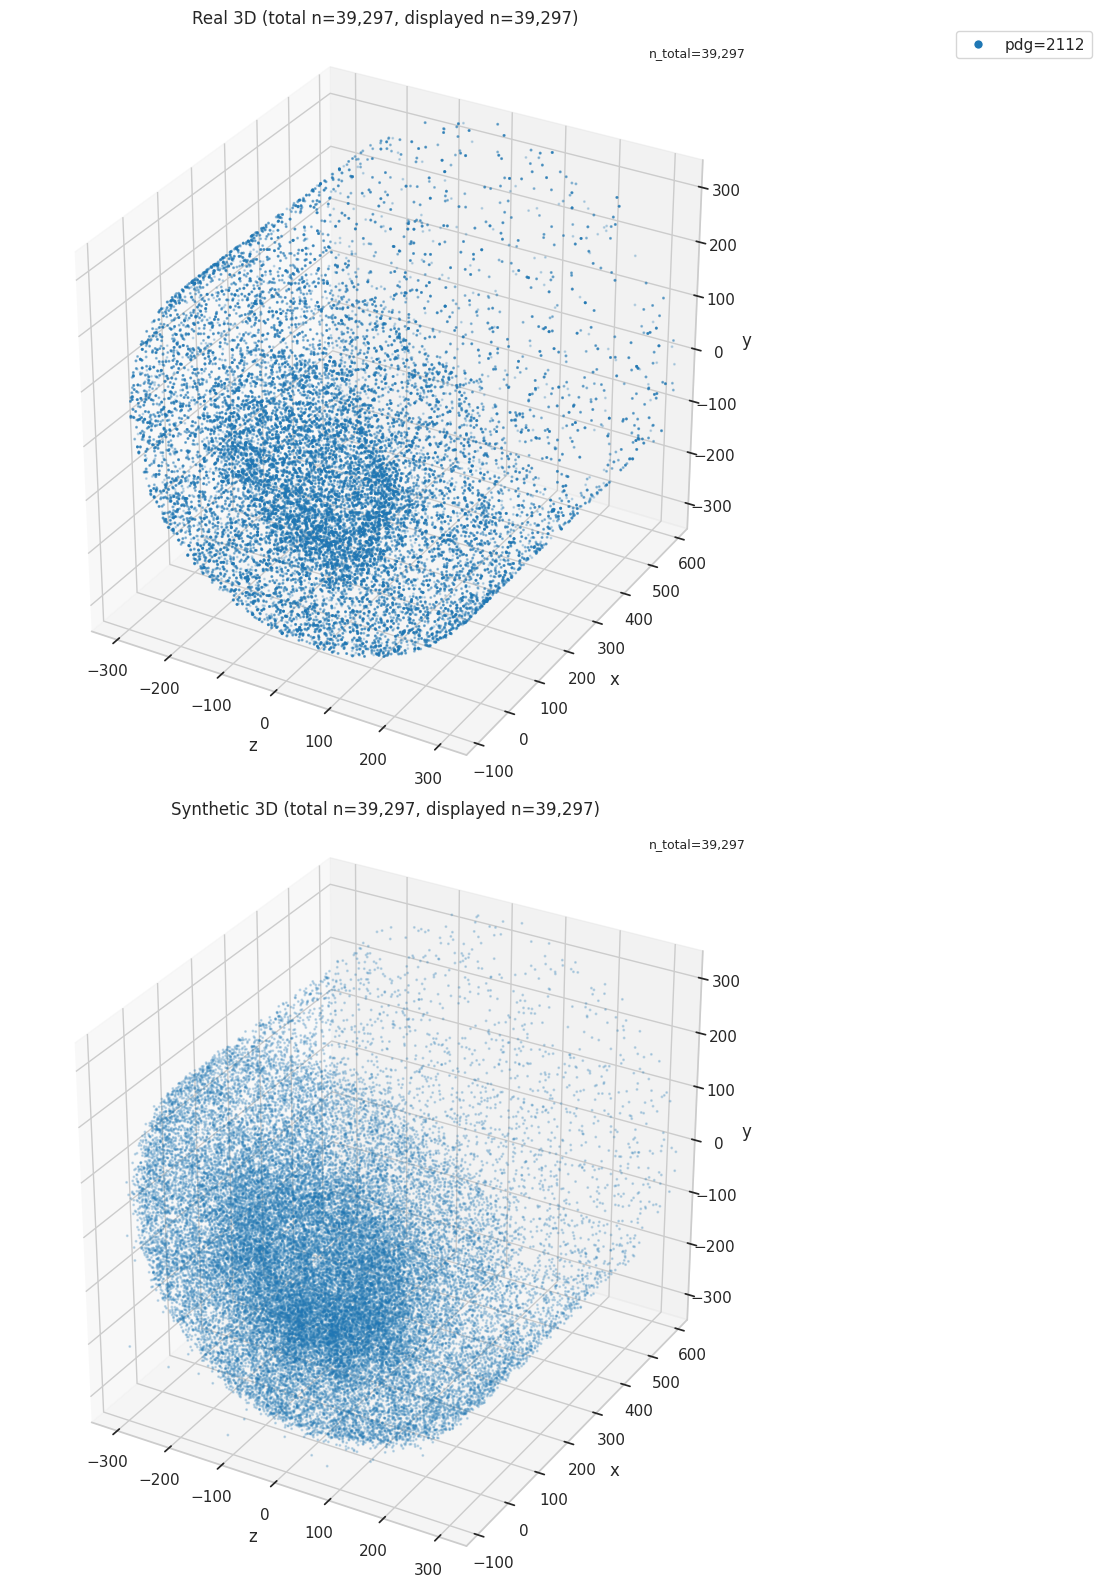

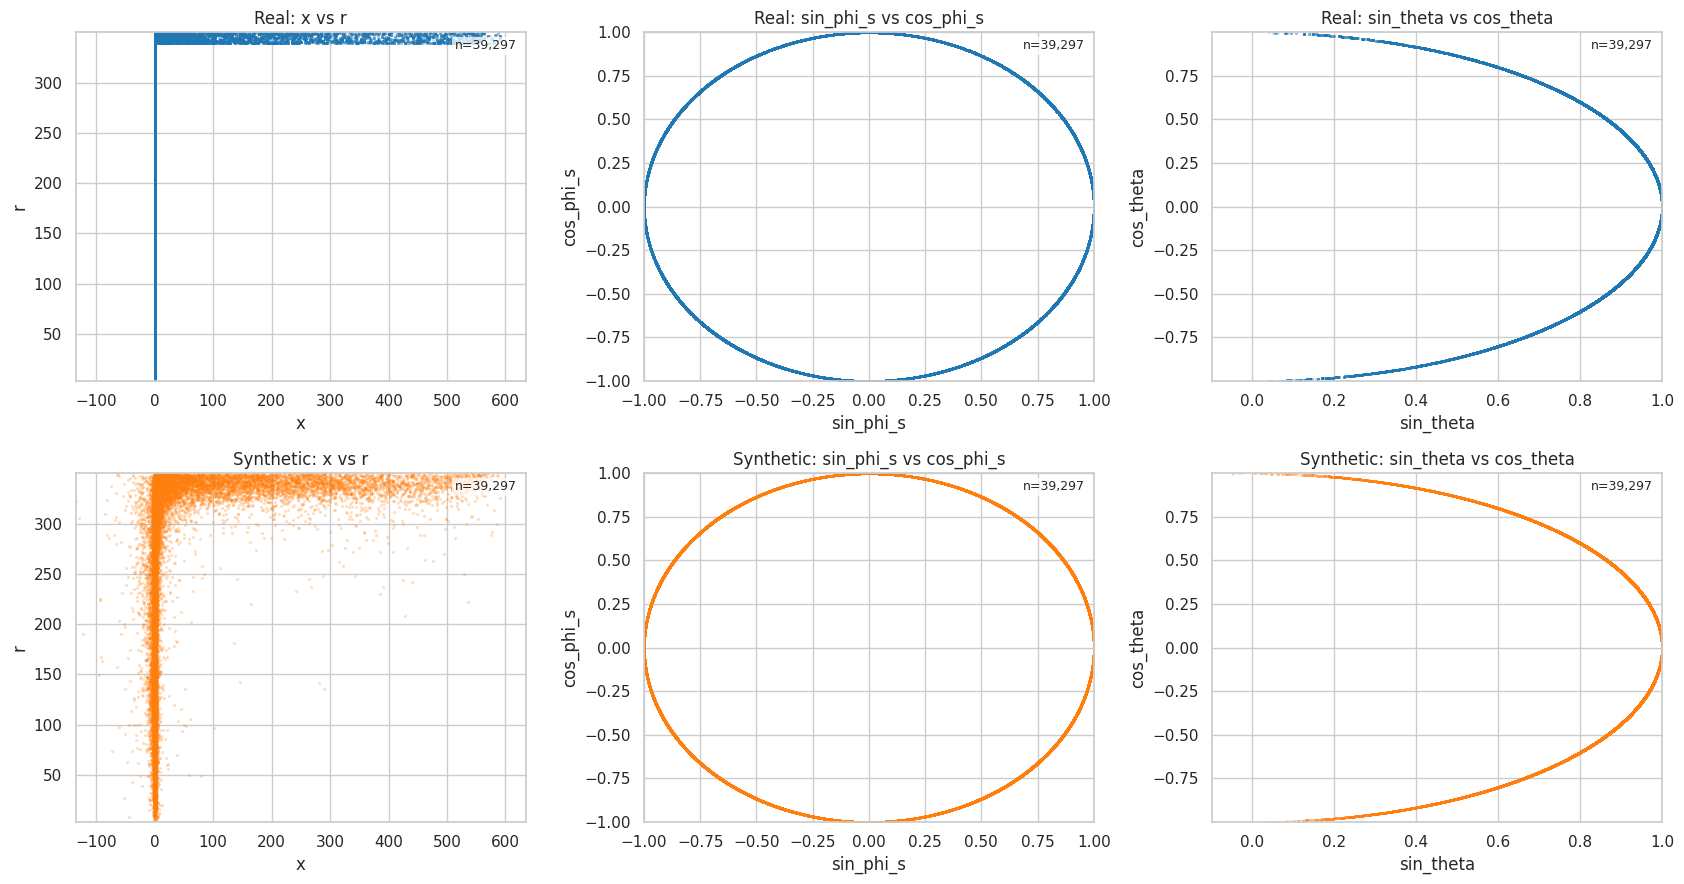

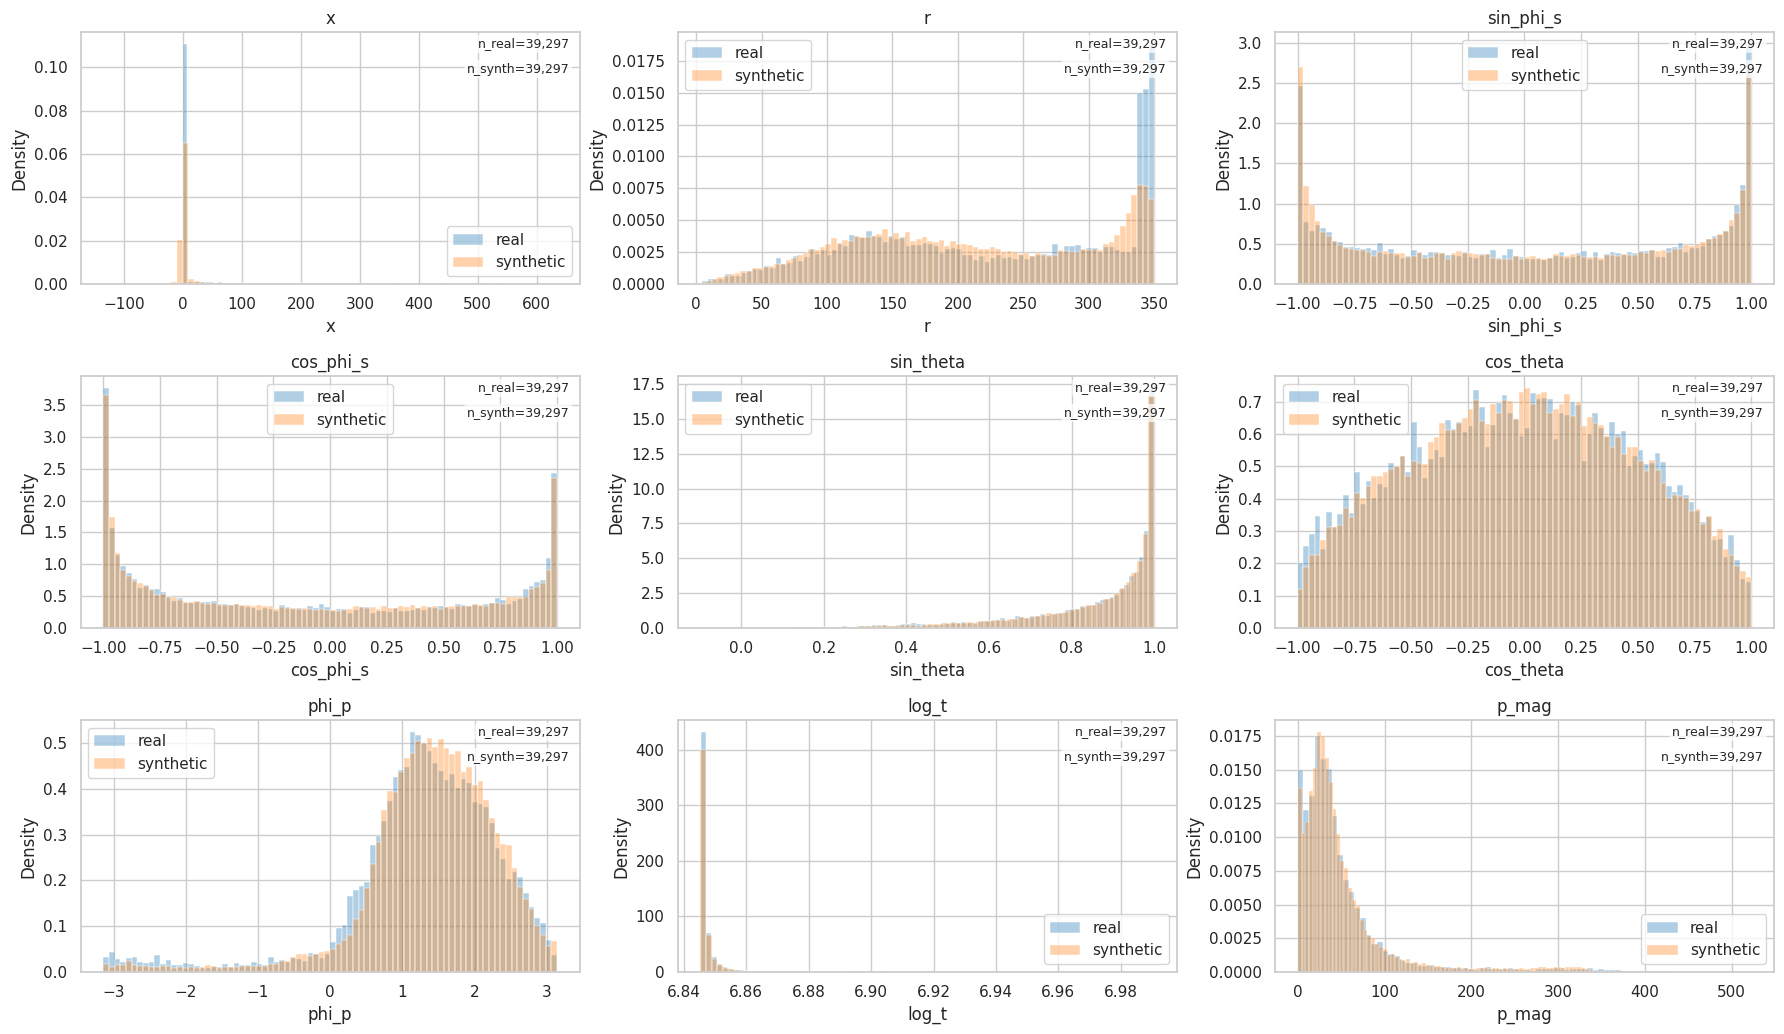

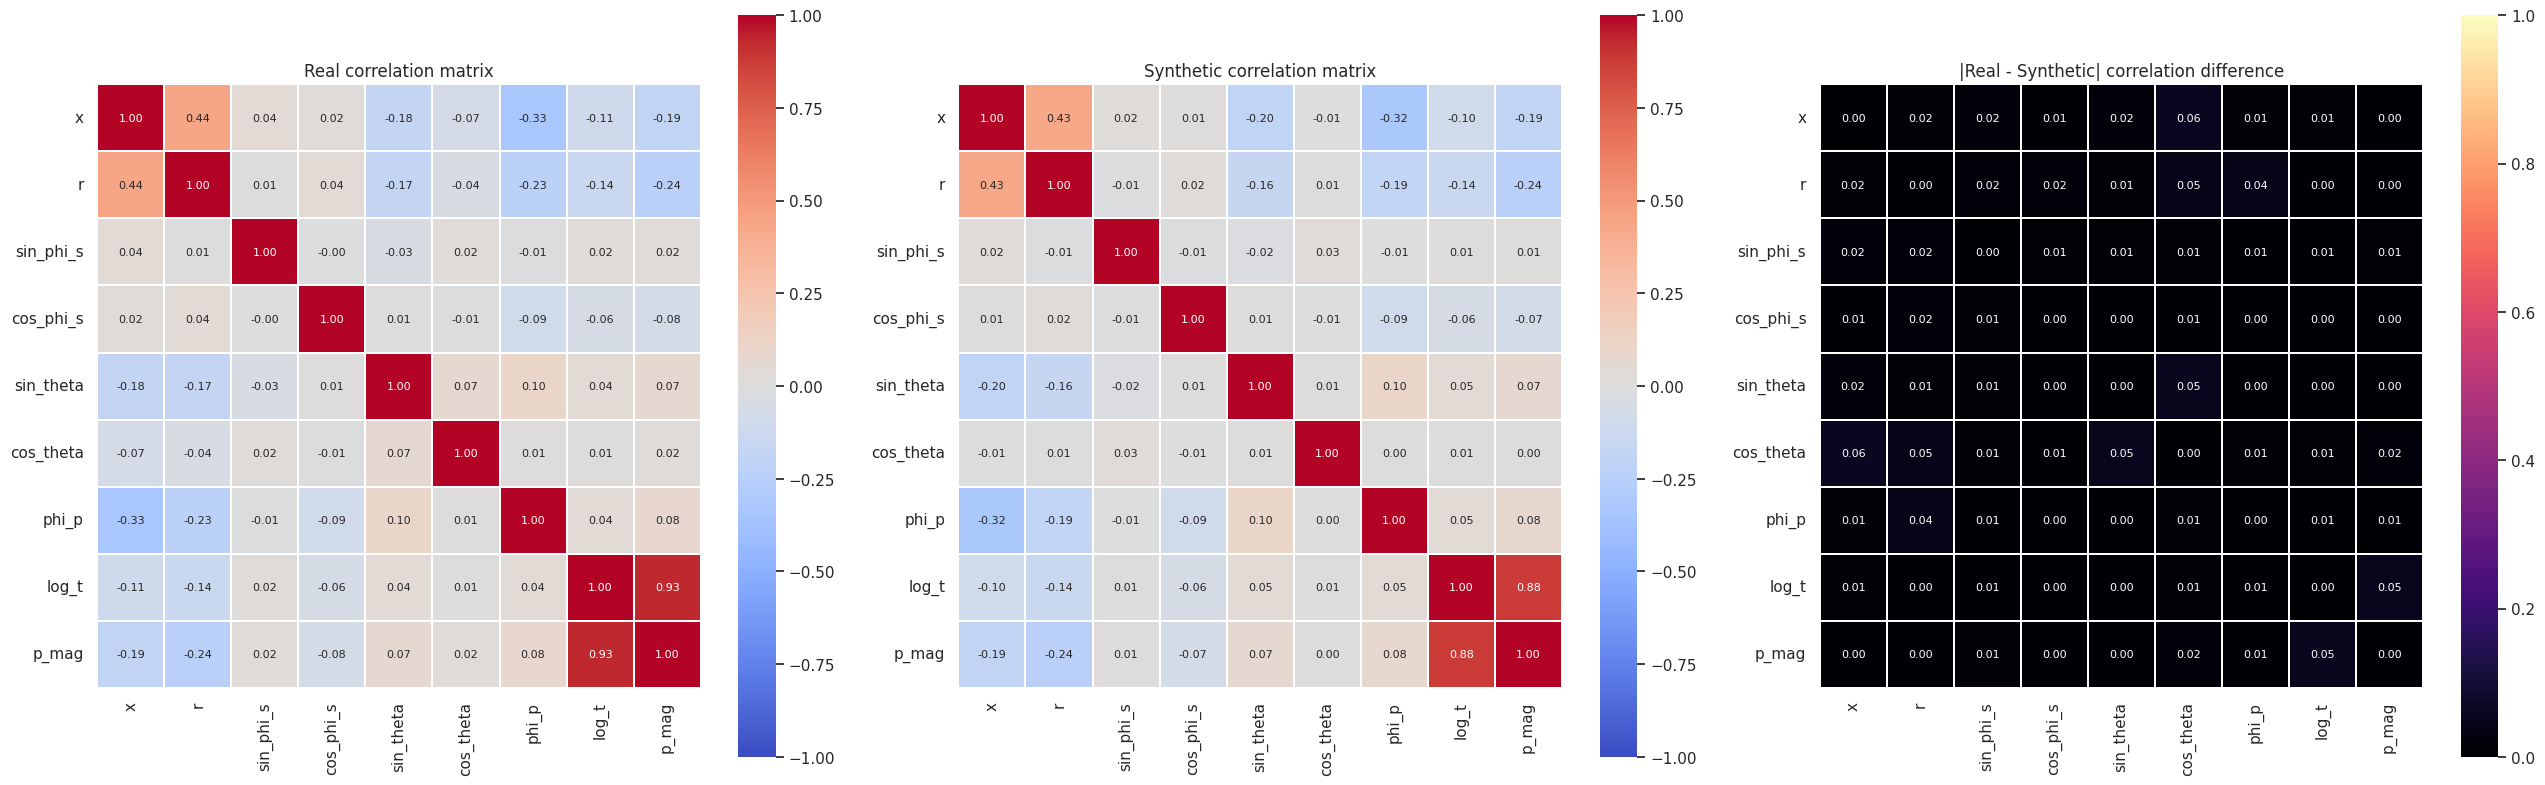

In [89]:
print_variable_means_before_plot(real_spill_df, synth_spill_df)
plot_3d_event_display(real_spill_df, synth_spill_df, max_points=200000)
plot_cylindrical_views(real_spill_df, synth_spill_df)
plot_cylindrical_marginals(real_spill_df, synth_spill_df)
plot_correlation_matrices(real_spill_df, synth_spill_df)

Count:    39,297
Unique:   2,400
Min:      -0.039999999999054126
Max:      591.0000000000018
Mean:     37.783600045338524
Std:      106.50255794659557

Value counts (top 20):
x
-0.040000      31661
-0.040000        122
 118.697898       10
 93.099153        10
 591.000000       10
 398.389542        9
 447.992216        9
 368.351934        9
 409.052054        9
 205.631572        9
 50.218619         9
 140.036955        8
 138.236443        8
 29.581655         8
 147.644676        8
 80.157887         8
 136.311996        8
 290.914434        8
 256.638696        8
 332.136968        8
Name: count, dtype: int64


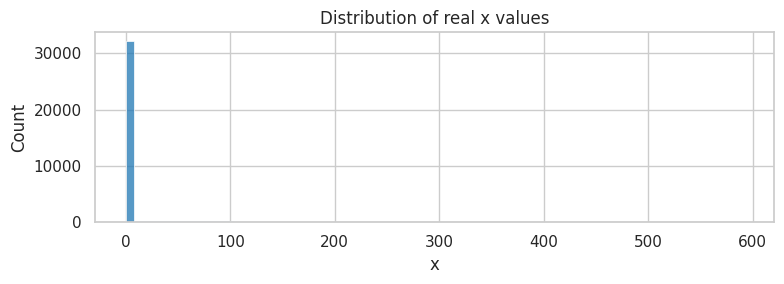

In [90]:
x_vals = real_spill_df['x'] if 'x' in real_spill_df.columns else None

if x_vals is None:
    print("'x' column not found in real_spill_df")
else:
    print(f"Count:    {len(x_vals):,}")
    print(f"Unique:   {x_vals.nunique():,}")
    print(f"Min:      {x_vals.min()}")
    print(f"Max:      {x_vals.max()}")
    print(f"Mean:     {x_vals.mean()}")
    print(f"Std:      {x_vals.std()}")
    print(f"\nValue counts (top 20):")
    print(x_vals.value_counts().head(20))
    
    plt.figure(figsize=(8, 3))
    if x_vals.nunique() > 1:
        sns.histplot(x_vals, bins=80, color='tab:blue')
        plt.title('Distribution of real x values')
    else:
        plt.text(0.5, 0.5, f'x is constant = {x_vals.iloc[0]}', ha='center', va='center', fontsize=14)
        plt.title('x is constant')
    plt.tight_layout()
    plt.show()